## XGBOOST

[I 2025-10-20 20:05:57,314] A new study created in memory with name: no-name-f1bde133-22a8-41f1-b032-278175c00815


Starting hyperparameter tuning with Optuna...


[I 2025-10-20 20:06:07,241] Trial 0 finished with value: 0.7559037297178579 and parameters: {'n_estimators': 237, 'max_depth': 7, 'learning_rate': 0.00860541619115923, 'subsample': 0.9910223791813795, 'colsample_bytree': 0.9580238114941845, 'gamma': 6.220684207826038, 'reg_alpha': 6.014675012682585e-08, 'reg_lambda': 1.6517929160574454e-07, 'min_child_weight': 19}. Best is trial 0 with value: 0.7559037297178579.
[I 2025-10-20 20:06:24,320] Trial 1 finished with value: 0.7579566056064839 and parameters: {'n_estimators': 817, 'max_depth': 9, 'learning_rate': 0.04541720529216723, 'subsample': 0.81925236807129, 'colsample_bytree': 0.528622187288849, 'gamma': 3.0320424247233078, 'reg_alpha': 0.008134068058157794, 'reg_lambda': 6.884558525891732e-07, 'min_child_weight': 9}. Best is trial 1 with value: 0.7579566056064839.
[I 2025-10-20 20:06:32,988] Trial 2 finished with value: 0.7534972669925774 and parameters: {'n_estimators': 395, 'max_depth': 2, 'learning_rate': 0.018038721112590556, 'sub

Best hyperparameters: {'n_estimators': 701, 'max_depth': 9, 'learning_rate': 0.03513504820577006, 'subsample': 0.6113219977044249, 'colsample_bytree': 0.5081162898338397, 'gamma': 4.094416995332675, 'reg_alpha': 1.6988809374776477e-07, 'reg_lambda': 4.4891220288717566e-05, 'min_child_weight': 13, 'random_state': 42, 'eval_metric': 'logloss', 'tree_method': 'hist', 'objective': 'binary:logistic'}
Best CV accuracy: 0.7581


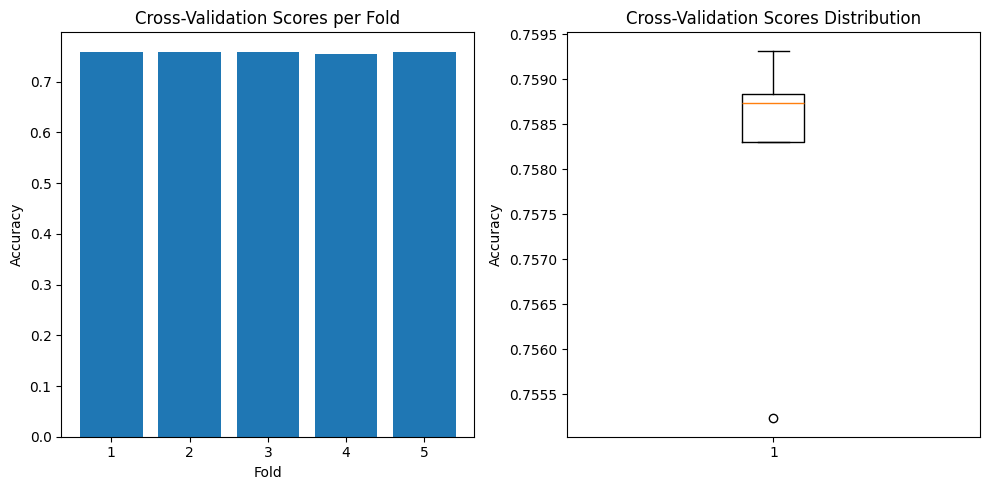

CV Scores: [0.75883968 0.7587367  0.75830759 0.75523515 0.75931616]
Mean CV Accuracy: 0.7581 (+/- 0.0029)

Test Accuracy: 0.7569

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.71      0.75     36413
         1.0       0.74      0.80      0.77     36412

    accuracy                           0.76     72825
   macro avg       0.76      0.76      0.76     72825
weighted avg       0.76      0.76      0.76     72825


Confusion Matrix:
[[25950 10463]
 [ 7238 29174]]


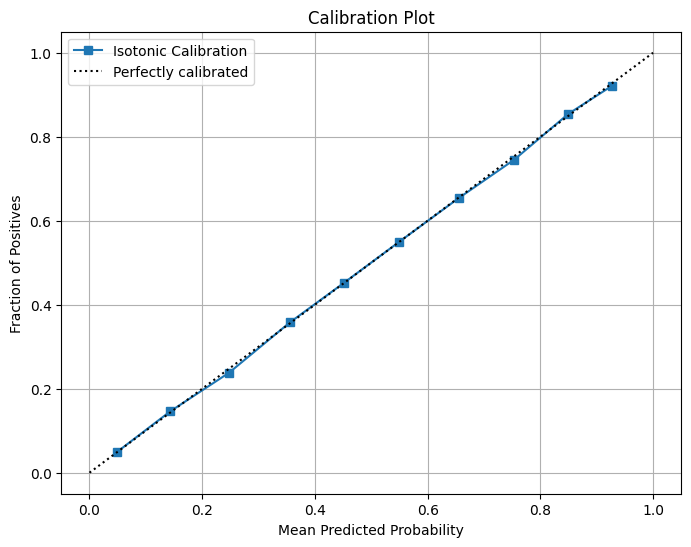


Calibrated model saved to: ../models/xgboost_calibrated_model.joblib


In [2]:
import os
import pandas as pd
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import optuna
import matplotlib.pyplot as plt
import numpy as np

# Configuration
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'
TARGET_COLUMN = 'has_diabetes'
MODEL_OUTPUT_DIR = '../models/'
MODEL_SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'xgboost_calibrated_model.joblib')
RANDOM_SEED = 42
N_TRIALS = 50
N_CV_FOLDS = 5

# Ensure model output directory exists
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Prepare features and target
X_train = train_df.drop(columns=TARGET_COLUMN)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(columns=TARGET_COLUMN)
y_test = test_df[TARGET_COLUMN]

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'random_state': RANDOM_SEED,
        'eval_metric': 'logloss',
        'tree_method': 'hist',  
        'objective': 'binary:logistic',
    }

    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# Best parameters
best_params = study.best_params
best_params.update({
    'random_state': RANDOM_SEED,
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'objective': 'binary:logistic'
})
print(f"Best hyperparameters: {best_params}")
print(f"Best CV accuracy: {study.best_value:.4f}")

# Train best model
best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)

# Cross-validation scores visualization
cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, N_CV_FOLDS + 1), cv_scores)
plt.title('Cross-Validation Scores per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, N_CV_FOLDS + 1))

plt.subplot(1, 2, 2)
plt.boxplot(cv_scores)
plt.title('Cross-Validation Scores Distribution')
plt.ylabel('Accuracy')

plt.tight_layout()
cv_plot_path = os.path.join(MODEL_OUTPUT_DIR, 'cv_scores_visualization.png')
plt.savefig(cv_plot_path)
plt.show()

print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Calibrate model for better probability estimates
calibrated_model = CalibratedClassifierCV(best_model, method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train)

# Predictions
y_pred = calibrated_model.predict(X_test)
y_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_proba, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, 's-', label='Isotonic Calibration')
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend()
plt.grid(True)
calibration_plot_path = os.path.join(MODEL_OUTPUT_DIR, 'calibration_plot.png')
plt.savefig(calibration_plot_path)
plt.show()

# Save model
joblib.dump(calibrated_model, MODEL_SAVE_PATH)
print(f"\nCalibrated model saved to: {MODEL_SAVE_PATH}")

## LightGBM

[I 2025-10-20 20:18:47,651] A new study created in memory with name: no-name-f31b5d88-6d03-440e-a80a-489a5ea28b71


Starting hyperparameter tuning with Optuna...


[I 2025-10-20 20:18:50,921] Trial 0 finished with value: 0.8338815916450872 and parameters: {'n_estimators': 428, 'max_depth': 6, 'learning_rate': 0.10643780512694678, 'num_leaves': 77, 'min_child_samples': 79, 'subsample': 0.994492089533431, 'colsample_bytree': 0.9263095197235038, 'reg_alpha': 5.156783470136284, 'reg_lambda': 9.333952020197081}. Best is trial 0 with value: 0.8338815916450872.
[I 2025-10-20 20:18:52,258] Trial 1 finished with value: 0.8337030903801413 and parameters: {'n_estimators': 105, 'max_depth': 11, 'learning_rate': 0.09655835213846231, 'num_leaves': 295, 'min_child_samples': 40, 'subsample': 0.7350199893921098, 'colsample_bytree': 0.9528306894348325, 'reg_alpha': 2.915208581872699, 'reg_lambda': 4.99678075722433}. Best is trial 0 with value: 0.8338815916450872.
[I 2025-10-20 20:18:54,875] Trial 2 finished with value: 0.8298373494727036 and parameters: {'n_estimators': 507, 'max_depth': 7, 'learning_rate': 0.1718339308119337, 'num_leaves': 218, 'min_child_samples


Best hyperparameters:
    n_estimators: 115
    max_depth: 7
    learning_rate: 0.088084352913117
    num_leaves: 56
    min_child_samples: 88
    subsample: 0.7937474295970551
    colsample_bytree: 0.7679616392657224
    reg_alpha: 6.347419202673964
    reg_lambda: 7.139324230405588

Test Accuracy: 0.7572
Test ROC-AUC: 0.8355

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.72      0.75     36413
         1.0       0.74      0.80      0.77     36412

    accuracy                           0.76     72825
   macro avg       0.76      0.76      0.76     72825
weighted avg       0.76      0.76      0.76     72825



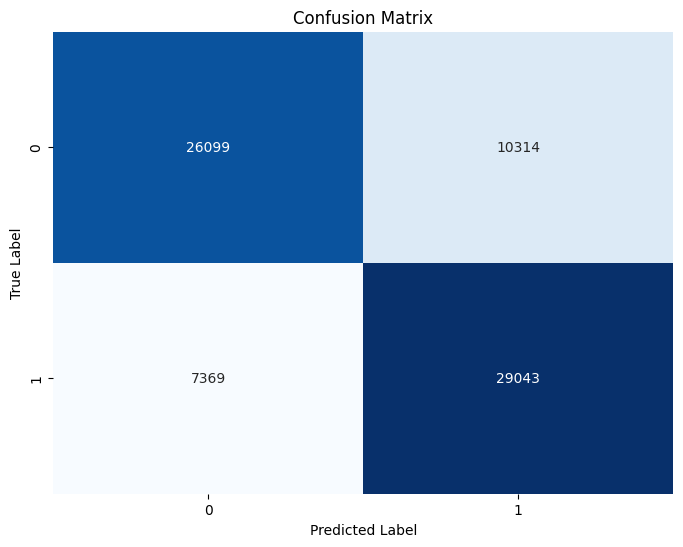

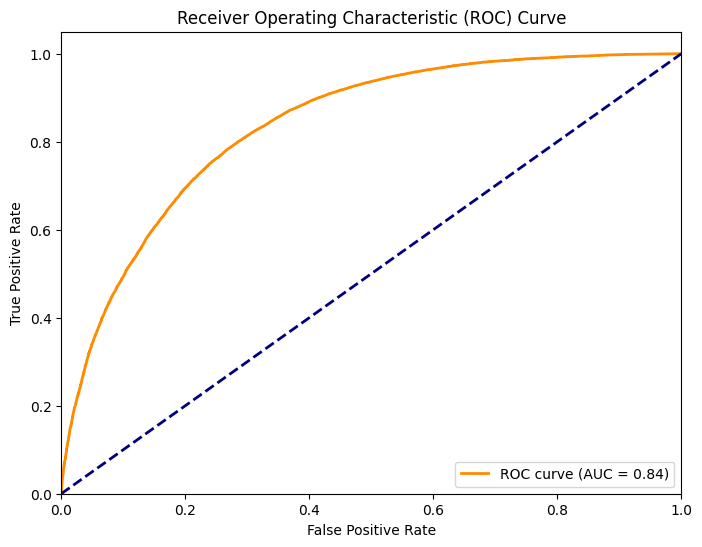

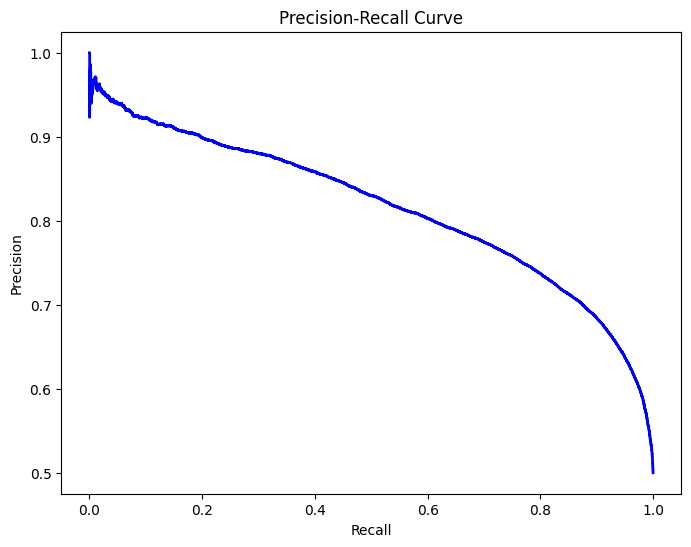


Model saved to: ../models/lightgbm_tuned_model.joblib


In [3]:
import os
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Configuration
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'
TARGET_COLUMN = 'has_diabetes'
MODEL_OUTPUT_DIR = '../models/'
MODEL_SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'lightgbm_tuned_model.joblib')
RANDOM_SEED = 42
N_TRIALS = 50  # Number of Optuna trials for tuning

# Ensure model output directory exists
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Load train and test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Prepare features and target
X_train = train_df.drop(columns=TARGET_COLUMN)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(columns=TARGET_COLUMN)
y_test = test_df[TARGET_COLUMN]

# Optuna objective function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': RANDOM_SEED,
        'verbose': -1,
        'objective': 'binary'
    }
    
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    return auc_score

# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# Print best parameters
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train final model with best params
best_params = study.best_params
best_params.update({
    'random_state': RANDOM_SEED,
    'verbose': -1,
    'objective': 'binary'
})
final_model = LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Save the trained model
joblib.dump(final_model, MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")

## CatBoost

[I 2025-10-20 20:23:45,328] A new study created in memory with name: no-name-c79f57bf-7d34-4473-a970-4f4aeff6941c


Starting hyperparameter tuning with Optuna...


[I 2025-10-20 20:24:15,429] Trial 0 finished with value: 0.8298718158944669 and parameters: {'iterations': 893, 'depth': 10, 'learning_rate': 0.06742072469830235, 'l2_leaf_reg': 3.790242304506223, 'border_count': 32, 'bagging_temperature': 0.36877153157139386, 'random_strength': 8.6580861876585}. Best is trial 0 with value: 0.8298718158944669.
[I 2025-10-20 20:24:21,908] Trial 1 finished with value: 0.8316230933400691 and parameters: {'iterations': 283, 'depth': 4, 'learning_rate': 0.01474864540915579, 'l2_leaf_reg': 4.841468238207431, 'border_count': 131, 'bagging_temperature': 0.7081626955871118, 'random_strength': 1.4120043890983125}. Best is trial 1 with value: 0.8316230933400691.
[I 2025-10-20 20:24:23,996] Trial 2 finished with value: 0.8352992391360532 and parameters: {'iterations': 198, 'depth': 4, 'learning_rate': 0.2962351200547667, 'l2_leaf_reg': 7.917548863023633, 'border_count': 196, 'bagging_temperature': 0.9568361961641061, 'random_strength': 7.731687624101086}. Best is 


Best hyperparameters:
    iterations: 600
    depth: 5
    learning_rate: 0.06494168500492324
    l2_leaf_reg: 8.783780262725896
    border_count: 147
    bagging_temperature: 0.5950365858528288
    random_strength: 9.392655033956773

Test Accuracy: 0.7580
Test ROC-AUC: 0.8359

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.72      0.75     36413
         1.0       0.74      0.80      0.77     36412

    accuracy                           0.76     72825
   macro avg       0.76      0.76      0.76     72825
weighted avg       0.76      0.76      0.76     72825



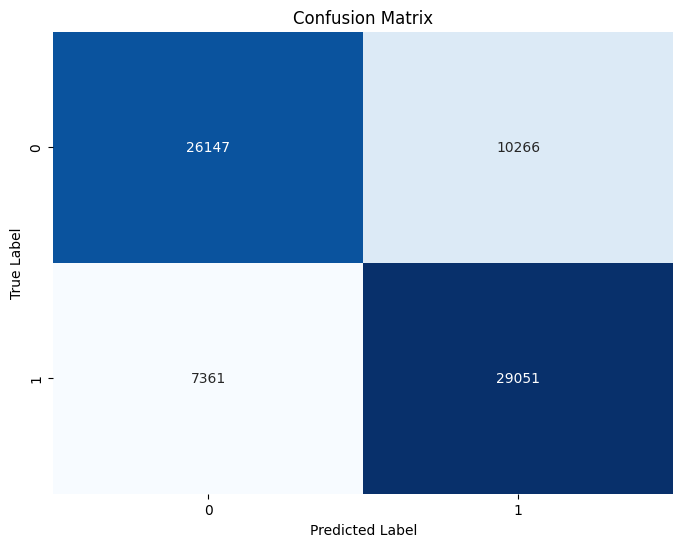

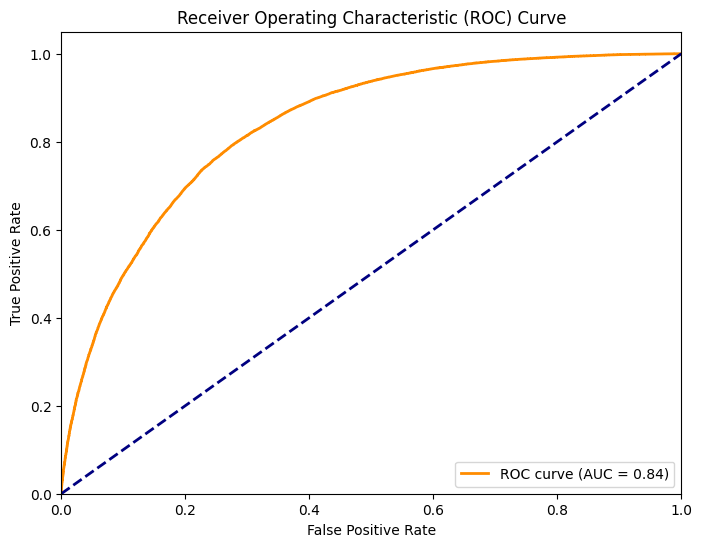

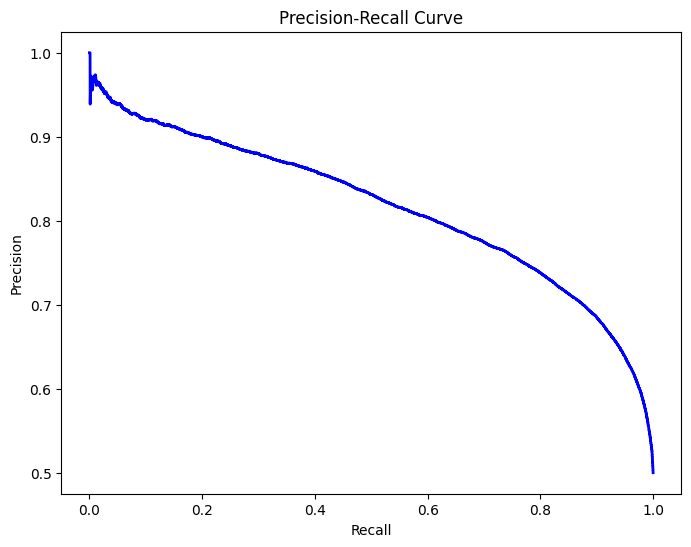


Model saved to: ../models/catboost_tuned_model.joblib


In [4]:
import os
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Configuration
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'
TARGET_COLUMN = 'has_diabetes'
MODEL_OUTPUT_DIR = '../models/'
MODEL_SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'catboost_tuned_model.joblib')
RANDOM_SEED = 42
N_TRIALS = 50

# Ensure model output directory exists
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Load train and test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Prepare features and target
X_train = train_df.drop(columns=TARGET_COLUMN)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(columns=TARGET_COLUMN)
y_test = test_df[TARGET_COLUMN]


# Optuna objective function
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),  # Affects speed/accuracy trade-off
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'random_seed': RANDOM_SEED,
        'verbose': False,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC'  
    }
    
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)  
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    return auc_score

# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# Print best parameters
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train final model with best params
best_params = study.best_params
best_params.update({
    'random_seed': RANDOM_SEED,
    'verbose': False,
    'loss_function': 'Logloss'
})
final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train, y_train)  # No cat_features

# Make predictions
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Save the trained model
joblib.dump(final_model, MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")

## Random Forest

[I 2025-10-20 20:35:09,335] A new study created in memory with name: no-name-7ab271e8-2bb6-4d4b-87cf-4b9bccd6715c


Starting hyperparameter tuning with Optuna...


[I 2025-10-20 20:35:15,489] Trial 0 finished with value: 0.8332574087292451 and parameters: {'n_estimators': 236, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.8332574087292451.
[I 2025-10-20 20:35:22,236] Trial 1 finished with value: 0.8307752474971615 and parameters: {'n_estimators': 85, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 0.8332574087292451.
[I 2025-10-20 20:35:24,297] Trial 2 finished with value: 0.8187207401778187 and parameters: {'n_estimators': 137, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.8332574087292451.
[I 2025-10-20 20:35:27,423] Trial 3 finished with value: 0.8220518582213264 and parameters: {'n_estimators': 184, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.8332574087292451.


Best hyperparameters:
    n_estimators: 263
    max_depth: 14
    min_samples_split: 16
    min_samples_leaf: 10
    max_features: sqrt

Test Accuracy: 0.7562
Test ROC-AUC: 0.8341

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.71      0.75     36413
         1.0       0.74      0.80      0.77     36412

    accuracy                           0.76     72825
   macro avg       0.76      0.76      0.76     72825
weighted avg       0.76      0.76      0.76     72825



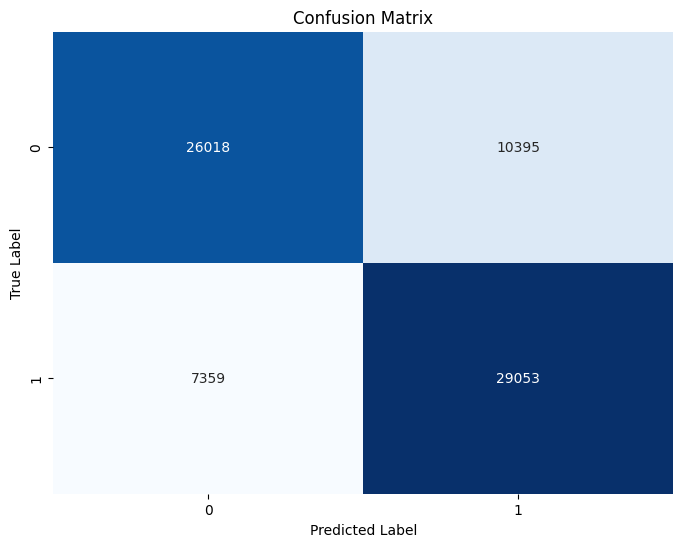

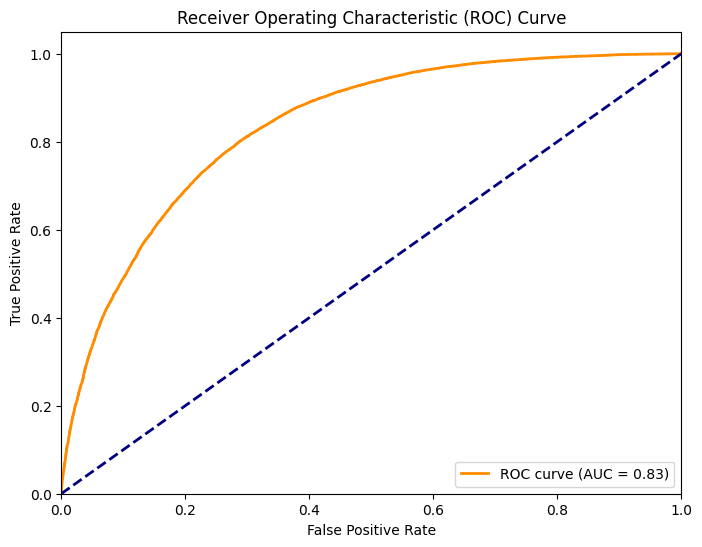

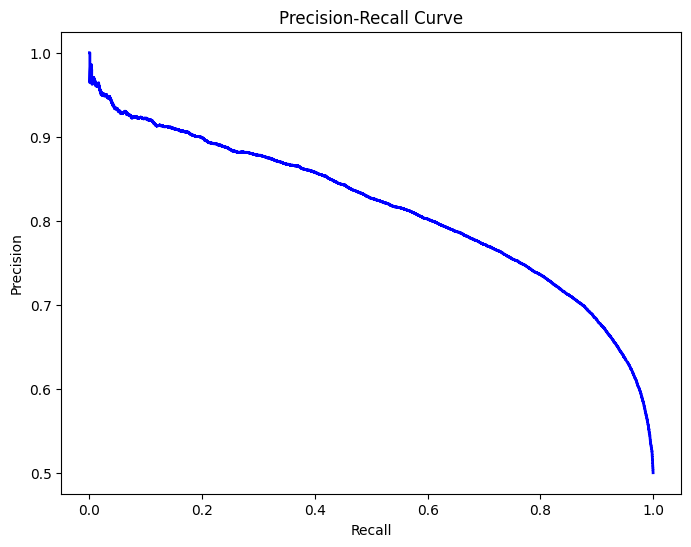


Model saved to: ../models/random_forest_tuned_model.joblib


In [5]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Configuration
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'
TARGET_COLUMN = 'has_diabetes'
MODEL_OUTPUT_DIR = '../models/'
MODEL_SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'random_forest_tuned_model.joblib')
RANDOM_SEED = 42
N_TRIALS = 50

# Ensure model output directory exists
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Load train and test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Prepare features and target
X_train = train_df.drop(columns=TARGET_COLUMN)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(columns=TARGET_COLUMN)
y_test = test_df[TARGET_COLUMN]

X_train_final = X_train
X_test_final = X_test

# Optuna objective function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': RANDOM_SEED,
        'n_jobs': 16  
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train_final, y_train)
    
    y_pred_proba = model.predict_proba(X_test_final)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    return auc_score

# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# Print best parameters
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train final model with best params
best_params = study.best_params
best_params.update({'random_state': RANDOM_SEED, 'n_jobs': -1})
final_model = RandomForestClassifier(**best_params)
final_model.fit(X_train_final, y_train)

# Make predictions
y_pred = final_model.predict(X_test_final)
y_pred_proba = final_model.predict_proba(X_test_final)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Save the trained model
joblib.dump(final_model, MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")

## Logistic Regression

[I 2025-10-20 20:42:43,179] A new study created in memory with name: no-name-0e814bda-5a9e-4339-8cb9-63a32fa0351f


Starting hyperparameter tuning with Optuna...


[I 2025-10-20 20:42:43,719] Trial 0 finished with value: 0.8263995184910098 and parameters: {'C': 0.09938223792873618, 'penalty': 'l1'}. Best is trial 0 with value: 0.8263995184910098.
[I 2025-10-20 20:42:44,271] Trial 1 finished with value: 0.8263995660069748 and parameters: {'C': 1.9358793276562698, 'penalty': 'l1'}. Best is trial 1 with value: 0.8263995660069748.
[I 2025-10-20 20:42:44,421] Trial 2 finished with value: 0.8263980292803272 and parameters: {'C': 6.796720180659704, 'penalty': 'l2'}. Best is trial 1 with value: 0.8263995660069748.
[I 2025-10-20 20:42:44,960] Trial 3 finished with value: 0.8263995871251816 and parameters: {'C': 2.5263426661107133, 'penalty': 'l1'}. Best is trial 3 with value: 0.8263995871251816.
[I 2025-10-20 20:42:45,101] Trial 4 finished with value: 0.8263972215089213 and parameters: {'C': 0.015912635683649614, 'penalty': 'l2'}. Best is trial 3 with value: 0.8263995871251816.
[I 2025-10-20 20:42:45,237] Trial 5 finished with value: 0.8263978784359938 an


Best hyperparameters:
    C: 0.010031149671559759
    penalty: l1

Test Accuracy: 0.7497
Test ROC-AUC: 0.8264

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74     36413
         1.0       0.74      0.77      0.75     36412

    accuracy                           0.75     72825
   macro avg       0.75      0.75      0.75     72825
weighted avg       0.75      0.75      0.75     72825



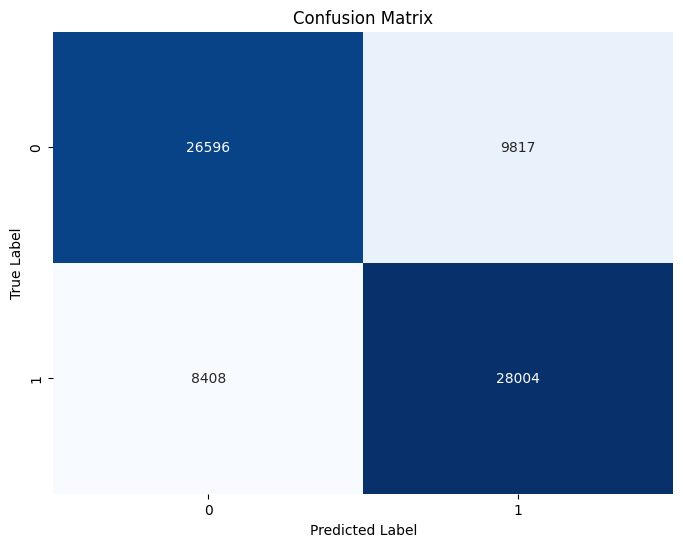

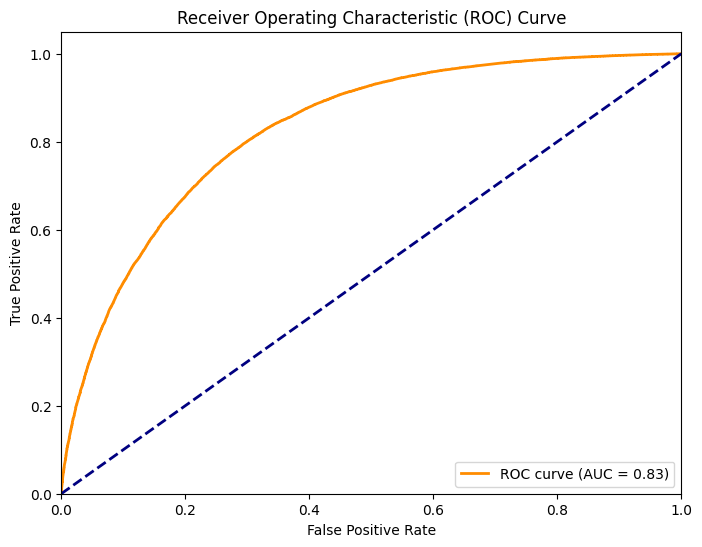

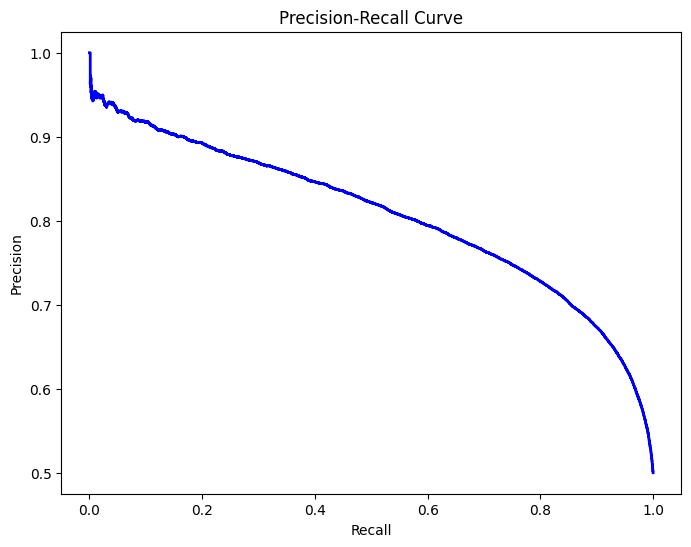


Model saved to: ../models/logistic_regression_tuned_model.joblib
Scaler saved to: ../models/standard_scaler_logistic_Tuned.joblib


In [6]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Configuration
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'
TARGET_COLUMN = 'has_diabetes'
MODEL_OUTPUT_DIR = '../models/'
MODEL_SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'logistic_regression_tuned_model.joblib')
RANDOM_SEED = 42
N_TRIALS = 50

# Ensure model output directory exists
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Load train and test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Prepare features and target
X_train = train_df.drop(columns=TARGET_COLUMN)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(columns=TARGET_COLUMN)
y_test = test_df[TARGET_COLUMN]


scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Optuna objective function
def objective(trial):
    # Suggest hyperparameters
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    
    # Choose solver compatible with penalty
    if penalty == 'l1':
        solver = 'liblinear'  # supports l1
    else:
        solver = 'lbfgs'  # default for l2, faster and more stable
    
    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        max_iter=2000,
        random_state=RANDOM_SEED
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    return auc_score

# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# Print best parameters
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train final model with best params
best_params = study.best_params
# Re-derive solver based on best penalty
solver = 'liblinear' if best_params['penalty'] == 'l1' else 'lbfgs'

final_model = LogisticRegression(
    **best_params,
    solver=solver,
    max_iter=2000,
    random_state=RANDOM_SEED
)
final_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = final_model.predict(X_test_scaled)
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Save model and scaler
joblib.dump(final_model, MODEL_SAVE_PATH)
joblib.dump(scaler, os.path.join(MODEL_OUTPUT_DIR, 'standard_scaler_logistic_Tuned.joblib'))

print(f"\nModel saved to: {MODEL_SAVE_PATH}")
print(f"Scaler saved to: {os.path.join(MODEL_OUTPUT_DIR, 'standard_scaler_logistic_Tuned.joblib')}")

## Simple Neural Network (MLP)

[I 2025-10-20 20:43:16,882] A new study created in memory with name: no-name-52b64642-a593-4367-8ed5-f27c4f41160b


Starting hyperparameter tuning with Optuna...


[I 2025-10-20 20:43:30,685] Trial 0 finished with value: 0.8347743461087452 and parameters: {'n_layers': 1, 'n_units_l1': 106, 'activation': 'relu', 'solver': 'adam', 'alpha': 3.689757210586661e-05, 'learning_rate': 'adaptive'}. Best is trial 0 with value: 0.8347743461087452.
[I 2025-10-20 20:43:51,190] Trial 1 finished with value: 0.8345618366116991 and parameters: {'n_layers': 2, 'n_units_l1': 69, 'n_units_l2': 49, 'activation': 'relu', 'solver': 'adam', 'alpha': 2.2924780231620668e-05, 'learning_rate': 'constant'}. Best is trial 0 with value: 0.8347743461087452.
[I 2025-10-20 20:44:20,502] Trial 2 finished with value: 0.8323178442520128 and parameters: {'n_layers': 1, 'n_units_l1': 180, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.002387432543143694, 'learning_rate': 'constant'}. Best is trial 0 with value: 0.8347743461087452.
[I 2025-10-20 20:45:01,038] Trial 3 finished with value: 0.8337729927756213 and parameters: {'n_layers': 1, 'n_units_l1': 50, 'activation': 'relu', 'solv


Best hyperparameters:
    activation: tanh
    solver: adam
    alpha: 2.7335564912096626e-05
    learning_rate: adaptive
    hidden_layer_sizes: (172,)

Test Accuracy: 0.7564
Test ROC-AUC: 0.8349

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.71      0.75     36413
         1.0       0.74      0.80      0.77     36412

    accuracy                           0.76     72825
   macro avg       0.76      0.76      0.76     72825
weighted avg       0.76      0.76      0.76     72825



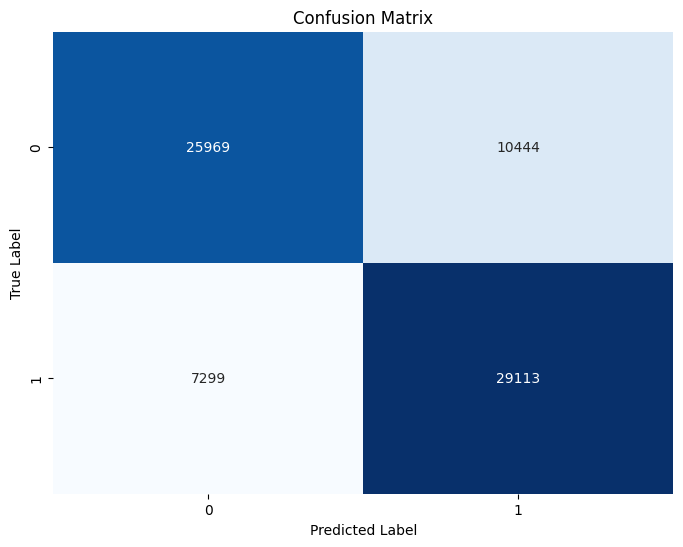

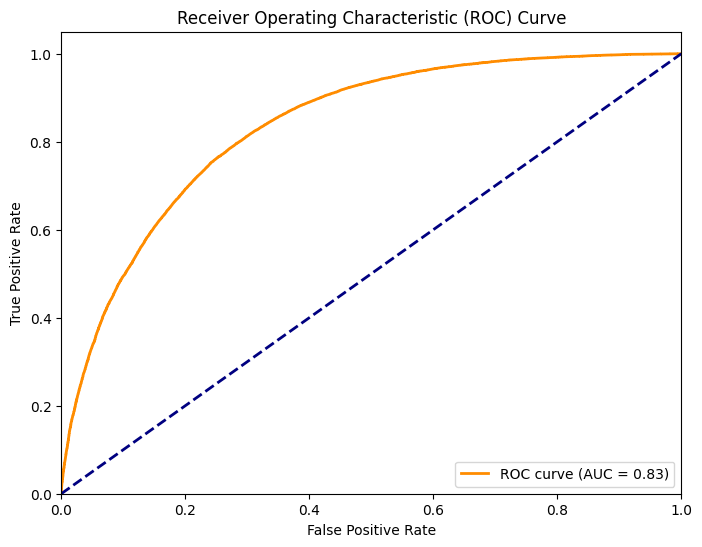

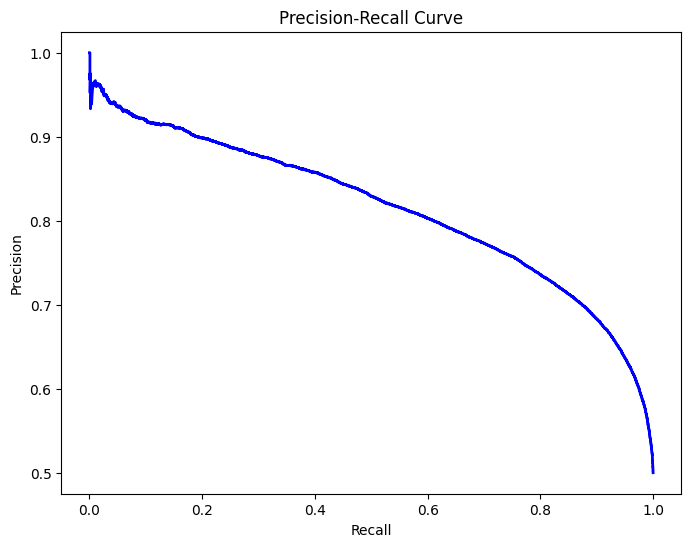


Model saved to: ../models/mlp_tuned_model.joblib
Scaler saved to: ../models/standard_scaler_mlp.joblib


In [7]:
import os
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Configuration
TRAIN_PATH = '../data/train-test/train_set.csv'
TEST_PATH = '../data/train-test/test_set.csv'
TARGET_COLUMN = 'has_diabetes'
MODEL_OUTPUT_DIR = '../models/'
MODEL_SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'mlp_tuned_model.joblib')
RANDOM_SEED = 42
N_TRIALS = 50

# Ensure model output directory exists
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Load train and test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Prepare features and target
X_train = train_df.drop(columns=TARGET_COLUMN)
y_train = train_df[TARGET_COLUMN]
X_test = test_df.drop(columns=TARGET_COLUMN)
y_test = test_df[TARGET_COLUMN]


scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Optuna objective function
def objective(trial):
    # Suggest number of hidden layers
    n_layers = trial.suggest_int('n_layers', 1, 2)
    if n_layers == 1:
        hidden_sizes = (trial.suggest_int('n_units_l1', 50, 200),)
    else:
        hidden_sizes = (
            trial.suggest_int('n_units_l1', 50, 200),
            trial.suggest_int('n_units_l2', 20, 100)
        )
    
    params = {
        'hidden_layer_sizes': hidden_sizes,
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'solver': trial.suggest_categorical('solver', ['adam', 'sgd']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),  # L2 regularization
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'max_iter': 1000,
        'random_state': RANDOM_SEED,
        'early_stopping': True,
        'validation_fraction': 0.1,
        'n_iter_no_change': 10
    }
    
    model = MLPClassifier(**params)
    model.fit(X_train_scaled, y_train)
    
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    return auc_score

# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# Extract best hidden_layer_sizes correctly
best_params = study.best_params.copy()
n_layers = best_params.pop('n_layers')
if n_layers == 1:
    hidden_sizes = (best_params.pop('n_units_l1'),)
else:
    hidden_sizes = (best_params.pop('n_units_l1'), best_params.pop('n_units_l2'))
best_params['hidden_layer_sizes'] = hidden_sizes

# Print best parameters
print("\nBest hyperparameters:")
for key, value in best_params.items():
    print(f"    {key}: {value}")

# Train final model with best params
final_model = MLPClassifier(
    **best_params,
    max_iter=1000,
    random_state=RANDOM_SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
final_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = final_model.predict(X_test_scaled)
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Save model and scaler
joblib.dump(final_model, MODEL_SAVE_PATH)
joblib.dump(scaler, os.path.join(MODEL_OUTPUT_DIR, 'standard_scaler_mlp.joblib'))

print(f"\nModel saved to: {MODEL_SAVE_PATH}")
print(f"Scaler saved to: {os.path.join(MODEL_OUTPUT_DIR, 'standard_scaler_mlp.joblib')}")

## Total Time = 3364.7S